# E01 - Direction mismatch, isolated from conditioning

Identity initialization makes every context singular value exactly 1, so spectral collapse
is absent by construction. Whatever stops a method from reaching `P*` here is the update
direction, not the conditioning.

Run the sweep first:

```bash
python -m olo.run configs/experiments/e01_deep_linear_identity.yaml \
  --sweep optim.type=als,adam,heavyball,muon,kfac,shampoo,soap \
  --sweep optim.lr=1.0,0.1,0.01,0.001,0.0001 --seeds 0,1,2
```


In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from olo.viz import load_runs, lr_grid, convergence, best_per, apply_style

apply_style()
runs = load_runs("../runs", "e01_*")
print(f"{len(runs)} runs, methods: {sorted({r.method for r in runs})}")

0 runs, methods: []


## Every method at its own best learning rate

A single shared learning rate would measure step-size scaling, not the methods. The left
panel shows each method's whole grid so its optimum is visible rather than asserted.

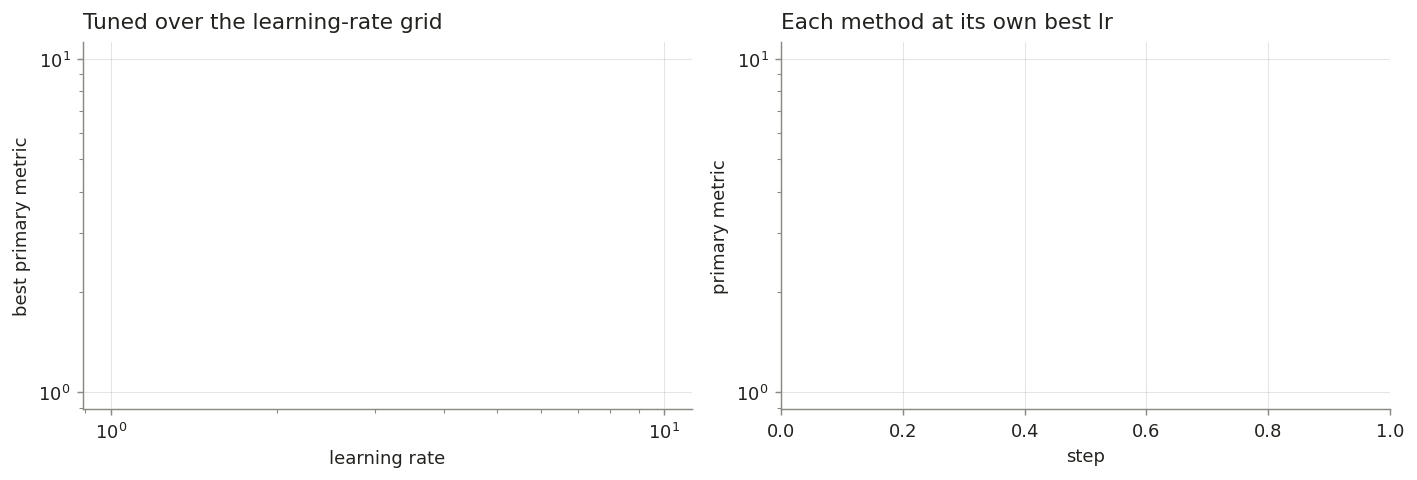

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
lr_grid(runs, ax=axes[0], title="Tuned over the learning-rate grid")
convergence(list(best_per(runs, "method").values()), ax=axes[1],
            title="Each method at its own best lr")
fig.tight_layout()
fig.savefig("../figures/e01_tuned_comparison.pdf")

## Does the mismatch diagnostic predict the outcome?

`cos_target` is measured per step and costs two operator evaluations. If it rank-orders
final error across methods, it is a cheap stand-in for running the comparison at all.

In [3]:
best = best_per(runs, "method")
print(f"{'method':11s} {'best err':>10s} {'cos@end':>9s}")
for m, r in sorted(best.items(), key=lambda kv: kv[1].best("eval_primary")):
    _, cos = r.series("cos_target")
    print(f"{m[0]:11s} {r.best('eval_primary'):10.3e} {cos[-1] if len(cos) else float('nan'):9.4f}")

method        best err   cos@end


## Operator spectrum over training

Starting from a flat spectrum, does the method keep it flat or destroy and rebuild it?

KeyError: ('als',)

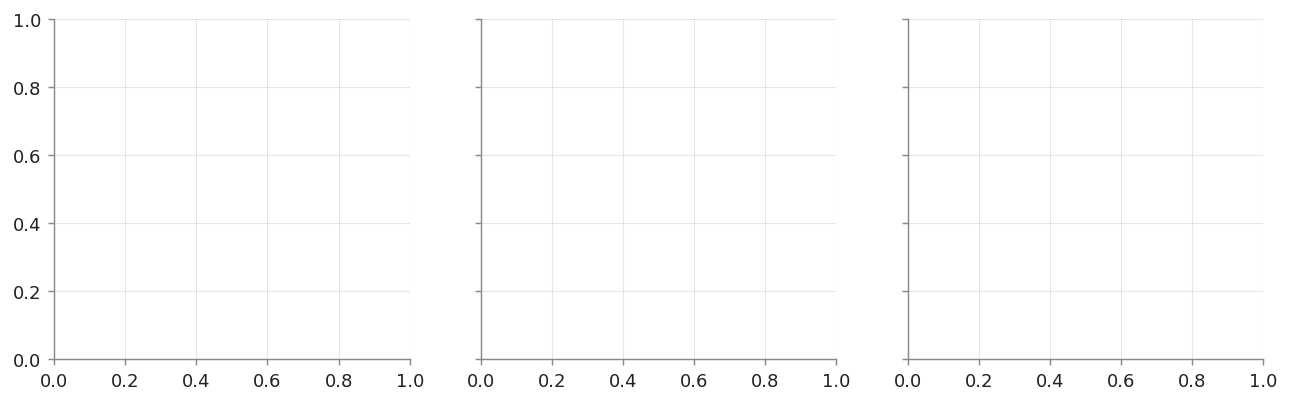

In [4]:
from olo.viz import spectrum
methods = ["als", "adam", "soap"]
fig, axes = plt.subplots(1, len(methods), figsize=(4 * len(methods), 3.4), sharey=True)
for ax, m in zip(axes, methods):
    spectrum(best[(m,)], ax=ax, title=m)
fig.tight_layout()
fig.savefig("../figures/e01_spectra.pdf")